In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import scene_generation.core as core_mod
import time

from pathlib import Path
from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size
from collections import Counter
from matplotlib.patches import Patch
from PIL import Image, ImageDraw
from sionna.rt import scene, preview

In [ ]:
# Scene center (only need to update CENTER_LON, CENTER_LAT, DATA_DIR_LIDAR_OSM, DATA_DIR_OVERTURE and run the rest of the cells to receive full analysis)
# DuPont Circle: -77.043446, 38.909647
# Duke Wilkinson area: -78.940297, 36.002556
# Flatiron Building: -73.9897, 40.7411
CENTER_LON = -74.00361
CENTER_LAT  = 40.715

SCENE_WIDTH  = 500   # east–west extent, metres
SCENE_HEIGHT = 500   # north–south extent, metres

DATA_DIR = "./scenes/nyc_cityhall_osm_without_lidar"

OSM_SERVER = "http://10.237.198.210:3452/api/interpreter"

In [9]:
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(DATA_DIR)}")

Output directory: /home/rt279/geo2sigmap-fork/research/examples/scenes/nyc_cityhall_example_overture_without_lidar


Using Overture release: s3://overturemaps-us-west-2/release/2026-06-17.0/theme=buildings/type=building/*


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Using Overture release: s3://overturemaps-us-west-2/release/2026-06-17.0/theme=buildings/type=building_part/*


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Parsing buildings:  31%|███       | 63/204 [00:00<00:00, 313.82it/s]

...

Building height source: overture:height, height: 20.0 m, building footprint: POLYGON ((584026.8124787096 4507391.174128075, 584029.5233763054 4507395.723376317, 584031.1314813903 4507398.439394515, 584032.8889851642 4507401.390248883, 584035.2598482057 4507405.380544247, 584034.7154881514 4507405.707440213, 583968.5738121013 4507444.881565762, 583968.148590381 4507445.132100466, 583964.0119899514 4507438.168691372, 583962.1551188509 4507435.039095899, 583959.668109767 4507430.85877483, 583960.1017786429 4507430.6083352305, 584026.3958243548 4507391.413654519, 584026.8124787096 4507391.174128075))
Building height source: overture:height, height: 25.0 m, building footprint: POLYGON ((583967.4912095283 4507407.677377134, 583970.4507622264 4507412.651296152, 583980.4096754192 4507406.768907489, 583972.9568350775 4507394.250226049, 583979.3948387506 4507390.448478441, 583980.7131248628 4507389.6640523765, 583982.0483046622 4507388.879817781, 583988.6649553184 4507384.969079627, 583996.05133

Building part 617a79c7-56df-351d-a7ba-e10199528a89 top height 74.10 exceeds parent building 6382b356-cc62-4e33-ad7b-93d0209db662 top height 30.50; treating min_height/min_floor as 0 for the part
Building part 6bb05881-494f-30a6-915d-46c068736c04 top height 34.90 exceeds parent building 6382b356-cc62-4e33-ad7b-93d0209db662 top height 30.50; treating min_height/min_floor as 0 for the part
Building part 21887833-1a7c-3845-9ecd-fb41a877a295 top height 64.70 exceeds parent building 9067208a-fd38-4e95-b912-16f00bbb3142 top height 27.10; treating min_height/min_floor as 0 for the part
Building part af95b41a-0054-3788-8ae3-03bc7d3719cd top height 133.40 exceeds parent building 9067208a-fd38-4e95-b912-16f00bbb3142 top height 27.10; treating min_height/min_floor as 0 for the part
Building part 550f5d49-ddb7-34e7-b51e-cadb5ac64257 top height 72.80 exceeds parent building 9067208a-fd38-4e95-b912-16f00bbb3142 top height 27.10; treating min_height/min_floor as 0 for the part
Building part b6f5836e-3

Building height source: overture:height, height: 39.2 m, building footprint: POLYGON ((584360.3866299692 4507621.053794265, 584359.3582062273 4507619.376785633, 584355.1955949931 4507612.512767215, 584360.8519995001 4507609.102136428, 584363.5569094807 4507607.467584047, 584368.7563851931 4507616.008713037, 584366.0174387724 4507617.66508058, 584360.3866299692 4507621.053794265))
Building height source: overture:height, height: 30.5 m, building footprint: POLYGON ((584346.0522468083 4507593.46863784, 584347.7279407581 4507592.455196539, 584390.9492075825 4507566.157417352, 584396.6315084622 4507562.702698946, 584402.8158217713 4507558.93173583, 584405.2741683181 4507557.438719933, 584414.9765923519 4507573.369598424, 584408.9786682042 4507614.956393368, 584367.2291956014 4507640.360431049, 584329.7841731398 4507663.149127932, 584320.4549689457 4507647.822115331, 584316.8974462528 4507641.9752865415, 584313.2072983475 4507635.90491052, 584303.239506154 4507619.527067895, 584304.29430843

,runtime_seconds
0,27.343858


,height_source,building_count,building_percentage
0,overture:height,303,95.28%
1,fallback:random,11,3.46%
2,overture:num_floors,4,1.26%


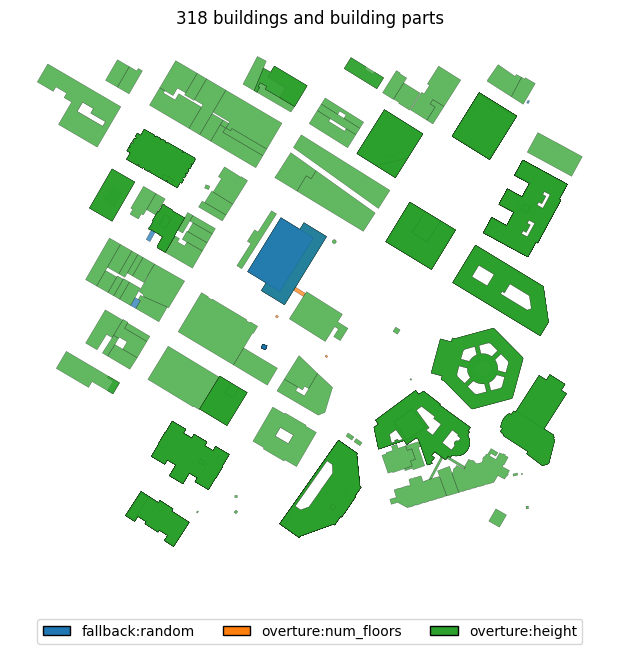

LiDAR HAG raster exists : False


In [ ]:
def summarize_height_sources(height_sources):
    """Summarize counts and percentages of buildings by selected height source."""
    total_buildings = sum(height_sources.values())
    rows = []

    for source, building_count in height_sources.most_common():
        building_percentage = (
            (building_count / total_buildings) * 100 if total_buildings else 0.0
        )
        rows.append(
            {
                "height_source": source,
                "building_count": building_count,
                "building_percentage": f"{building_percentage:.2f}%",
            }
        )

    return pd.DataFrame(
        rows,
        columns=["height_source", "building_count", "building_percentage"],
    )


def iter_polygons(geometry):
    """Yield polygon parts from a Shapely Polygon or MultiPolygon."""
    if geometry is None or geometry.is_empty:
        return

    if geometry.geom_type == "Polygon":
        yield geometry
    elif geometry.geom_type == "MultiPolygon":
        yield from geometry.geoms


def plot_height_source_footprints(
    records, *, figsize=(14, 7), alpha=0.75
):
    """Plot building footprints, colored by height source."""
    all_sources = list(dict.fromkeys(
    record["height_source"] for record in records
    ))
    cmap = plt.get_cmap("tab10")
    source_colors = {
        source: cmap(index % cmap.N) for index, source in enumerate(all_sources)
    }

    fig, axes = plt.subplots(1, 1, figsize=figsize)
    for record in records:
        source = record["height_source"]
        for polygon in iter_polygons(record["footprint"]):
            x, y = polygon.exterior.xy
            axes.fill(
                x,
                y,
                facecolor=source_colors[source],
                edgecolor="black",
                linewidth=0.2,                    alpha=alpha,
            )
            for interior in polygon.interiors:
                hole_x, hole_y = interior.xy
                axes.fill(
                    hole_x,
                    hole_y,
                    facecolor="white",
                    edgecolor="black",
                    linewidth=0.2,
                )

    axes.set_title(f"{len(records)} buildings and building parts")
    axes.set_aspect("equal", adjustable="box")
    axes.axis("off")

    legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=source)
        for source, color in source_colors.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=max(1, min(4, len(legend_handles))),
    )
    return fig, axes

def generate_scene(out_dir, *, track_height_sources=False):
    """Generate the scene and optionally count selected height sources."""
    scene_polygon = rect_from_point_and_size(
    CENTER_LON, CENTER_LAT, "center", SCENE_WIDTH, SCENE_HEIGHT
    )

    height_sources = []
    height_source_records = []
    original_resolve = core_mod.resolve_building_height

    def logging_resolve_building_height(*args, **kwargs):
        kwargs = dict(kwargs)
        kwargs["return_source"] = True
        height, metadata = original_resolve(*args, **kwargs)
        source = metadata.get("source", "unknown")
        footprint = args[1] if len(args) > 1 else kwargs.get("building_polygon")
        height_sources.append(source)
        height_source_records.append(
            {
                "height_source": source,
                "height_m": height,
                "footprint": footprint,
            }
        )
        print(f"Building height source: {source}, height: {height} m, building footprint: {footprint}")
        return height

    if track_height_sources:
        core_mod.resolve_building_height = logging_resolve_building_height

    try:
        scene = Scene()
        building_height_map = scene(
            points=scene_polygon,
            data_dir=out_dir,
            hag_tiff_path=None,  # None lets lidar-osm create/reuse out_dir/test_hag.tif
            osm_server_addr = "http://10.237.198.210:3452/api/interpreter",
            ground_material_type="mat-itu_wet_ground",
            rooftop_material_type="mat-itu_metal",
            wall_material_type="mat-itu_concrete",
            generate_building_map=True,
            lidar_height_calibration=False,
            building_data_source="osm",
            #lidar_terrain=False,
            #dem_terrain=False,
        )
        ground_bounds = scene._ground_polygon_envelope_UTM.bounds
    finally:
        if track_height_sources:
            core_mod.resolve_building_height = original_resolve

    return building_height_map, Counter(height_sources), height_source_records, ground_bounds

scene_generation_runtimes = []

# start_time = time.perf_counter()
# lidar_height_map, lidar_height_sources, lidar_height_source_records, lidar_ground_bounds = generate_scene(
#     "lidar-osm", DATA_DIR_LIDAR_OSM, track_height_sources=True
# )
# scene_generation_runtimes.append(
#     {"mode": "lidar-osm", "runtime_seconds": time.perf_counter() - start_time}
# )

start_time = time.perf_counter()
overture_height_map, overture_height_sources, overture_height_source_records, overture_ground_bounds = generate_scene(
    DATA_DIR, track_height_sources=True
)
scene_generation_runtimes.append(
    {"runtime_seconds": time.perf_counter() - start_time}
)

print("Scene generation complete!")
scene_generation_runtime_summary = pd.DataFrame(scene_generation_runtimes)
display(scene_generation_runtime_summary)

height_source_summary = pd.concat(
    [
        summarize_height_sources(overture_height_sources),
    ],
    ignore_index=True,
)
display(height_source_summary)
plot_height_source_footprints(overture_height_source_records)
plt.show()
print("LiDAR HAG raster exists :", (Path(DATA_DIR) / "test_hag.tif").exists())

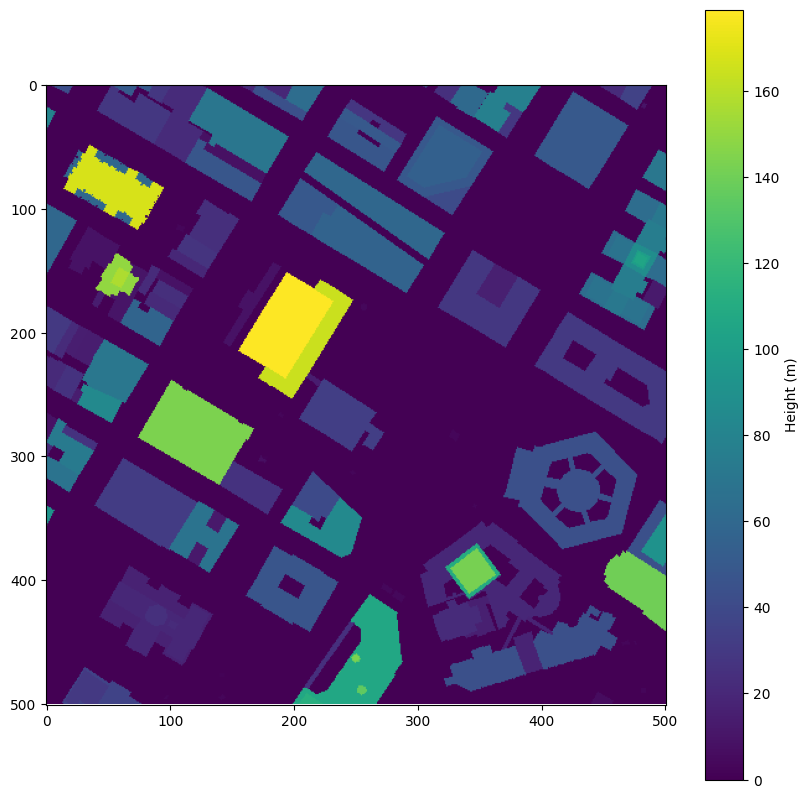

In [11]:
overture_map = np.load(Path(DATA_DIR) / "2D_Building_Height_Map.npy")

# show overture map with colormap
plt.figure(figsize=(10, 10))
plt.imshow(overture_map, cmap="viridis", origin="upper")
# show scale of colors
plt.colorbar(label="Height (m)")
plt.show()

In [12]:
overture_sionna_scene = scene.load_scene(DATA_DIR + "/scene.xml")
overture_sionna_scene.preview()

2026-07-07 21:24:00 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
